# Chapter 10 - Sorting and Searching

## Sorting Algorithms

### Bubble sort
- Swap current and next elements until array is sorted.
- Largest will bubble up at end, so it wont have to be sorted in next step (n-k-1).
- Runtime: 0(n2) average and worst case.
- Memory: 0(1).

In [11]:
def bubble(arr, verbose=False):
    n = len(arr)
    for k in range(0, n):
        if verbose: print(k, arr)
        swaps = 0
        for i in range(0, n-k-1):
            cur = arr[i]
            adj = arr[i+1]
            if cur > adj:
                arr[i] = adj
                arr[i+1] = cur
                swaps += 1
        if swaps == 0: break

arr = [2,3,6,8,1]
arr = [1,2,3,4,5]
verbose = True
bubble(arr, verbose)
print(arr)

0 [1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]


### Selection sort
- Swap min and first "untouched" element
- Runtime: O(n2) average and worst case.
- Memory: O(1)

In [7]:
def selection(arr, verbose=False):
    n = len(arr)
    istart = 0
    for k in range(0, n-1):
        if verbose: print(k, arr)
        vmin = 2^31-1
        imin = -1
        ibeg = k
        vbeg = arr[ibeg]
        # find min
        for i in range(k,n):
            vcur = arr[i]
            if vcur < vmin:
                vmin = arr[i]
                imin = i
        # swap
        arr[ibeg] = vmin
        arr[imin] = vbeg
        

verbose = True
print('unsorted')
arr = [2,3,6,8,1]
selection(arr, verbose)
print('sorted')
sort = [1,2,3,4,5]
selection(sort, verbose)


unsorted
0 [2, 3, 6, 8, 1]
1 [1, 3, 6, 8, 2]
2 [1, 2, 6, 8, 3]
3 [1, 2, 3, 8, 6]
sorted
0 [1, 2, 3, 4, 5]
1 [1, 2, 3, 4, 5]
2 [1, 2, 3, 4, 5]
3 [1, 2, 3, 4, 5]


### Merge sort
- Splits array in half recursively, and merges the two lists
- [Video](https://www.youtube.com/watch?v=TzeBrDU-JaY&list=PL2_aWCzGMAwKedT2KfDMB9YA5DgASZb3U&index=5)
- Recurssive: Need a merger method and a recursive method
- Divide and conquer
- Stable: ties will appear in original order
- Not in-place
- O( n log (n) ) average and worst case. 
- Memory: Depends O(n)

In [10]:
# merges two arrays
def merger(left, right, arr):
    nL = len(left)
    nR = len(right)
    i = 0 # current position in left
    j = 0 # current position in right
    k = 0 # current position in arr

    # merging loop
    while i < nL and j < nR:
        if left[i] <= right[j]:
            arr[k] = left[i]
            i += 1
        else:
            arr[k] = right[j]
            j += 1
        k += 1

    # emptying loops
    while i < nL:
        arr[k] = left[i]
        i += 1
        k += 1

    while j < nR:
        arr[k] = right[j]
        j += 1
        k += 1

def merge(arr, verbose=False):
    n = len(arr)
    if n < 2: return 

    imid = n // 2
    left = arr[0:imid]
    right = arr[imid:]
    merge(left, verbose)
    merge(right, verbose)
    merger(left, right, arr)
    if verbose: print(left, right)

verbose = True
print('unsorted')
arr = [2,3,6,8,1]
merge(arr, verbose)
print(arr)
print('sorted')
sort = [1,2,3,4,5]
merge(sort, verbose)
print(sort)
    

unsorted
[2] [3]
[8] [1]
[6] [1, 8]
[2, 3] [1, 6, 8]
[1, 2, 3, 6, 8]
sorted
[1] [2]
[4] [5]
[3] [4, 5]
[1, 2] [3, 4, 5]
[1, 2, 3, 4, 5]


### Quick sort
- Moves elements before or after a selected pivot (recursive)
- [Video](https://www.youtube.com/watch?v=COk73cpQbFQ&t=1s)
- Divide and conquer (recursive)
- In-place
- Not stable: 
- Partion function rearranges and return the partition index
- Runtime: 0 (n log (n)) average, 0 (n2) worst case (can be avoided with randomization)
- Memory: 0 (log (n) )

In [20]:
def partition(arr, start, end):
    # select pivot
    ipivot = end
    pivot = arr[ipivot]
    p = start
    for i in range(start,end):
        vi = arr[i]
        vp = arr[p]
        # swap values if val at i less than val at p
        if vi <= pivot:
            arr[i] = vp
            arr[p] = vi
            p += 1
    # swap pivot and value at p
    vp = arr[p]
    arr[p] = pivot
    arr[ipivot] = vp
    return p

def quicksort(arr, start=None, end=None, verbose=False):
    n = len(arr)
    if start == None: start = 0
    if end == None: end = n-1
    # base case
    if start >= end: return
    # find pivot
    p = partition(arr, start, end)
    # recursive call on left and right
    if verbose: print(arr[start:p],arr[p],arr[p+1:end+1])
    quicksort(arr, start, p-1, verbose)
    quicksort(arr, p+1, end, verbose)
    


verbose = True
print('unsorted')
arr = [2,3,6,8,5]
quicksort(arr, verbose=verbose)
print(arr)
print('sorted')
sort = [1,2,3,4,5]
quicksort(sort, verbose=verbose)
print(sort)


unsorted
[2, 3] 5 [8, 6]
[2] 3 []
[] 6 [8]
[2, 3, 5, 6, 8]
sorted
[1, 2, 3, 4] 5 []
[1, 2, 3] 4 []
[1, 2] 3 []
[1] 2 []
[1, 2, 3, 4, 5]


### Counting sort
- [Video](https://www.youtube.com/watch?v=OKd534EWcdk&t=34s)
- [Geeks](https://www.geeksforgeeks.org/counting-sort/)
- Create dictionary of counts
- Create dictionary of cuml sum of counts

In [51]:
def counting_sort(arr, maxint=None, verbose=False):
    if maxint == None: maxint = max(arr) + 1
    counts = [0]*maxint
    for val in arr:
        counts[val] += 1
    if verbose: print(counts)

    for i in range(1, len(counts)):
        counts[i] = counts[i-1] + counts[i]

    if verbose: print(counts)
    results = [0]*(len(counts))

    for val in arr:
        pos = counts[val]
        counts[val] += 1
        results[pos] = val

    if verbose: print(results)
    
    return results[1:]

arr = [1,4,1,2,7,5,2]
print(counting_sort(arr))

[0, 1, 1, 2, 2, 5, 7]


### Radix sort
- [Video](https://www.youtube.com/watch?v=XiuSW_mEn7g)
- [Geeks](https://www.geeksforgeeks.org/radix-sort/)
- stable sort
- call count_sort with increasing exp=1,10,11
- last count_sort loop needs to be in reverse!
- Runtime O(d(n+b)) or O(kn), good for b/<n
  - b = base
  - d = num digits
  - n = array length

In [35]:
def counting_sort(arr, exp1):
    n = len(arr)
    results = [0]*(n+1)
    counts = [0]*(10)

    # get digit and add to counts
    for val in arr:
        dig = int(val/exp1) % 10
        counts[dig] += 1

    for i in range(1, len(counts)):
        counts[i] = counts[i-1] + counts[i]

    for i in range(n-1, 0, -1):
        val = arr[i]
        dig = int(val/exp1) % 10
        index = counts[dig]
        results[index] = val
        counts[dig] -= 1

    for i in range(0, len(arr)):
        arr[i] = results[i+1]
    return arr
    

def radix_sort(arr, verbose=False):
    max1 = max(arr)
    
    exp1 = 1

    while exp1 < max1:
        counting_sort(arr, exp1)
        if verbose: print(exp1, arr)
        exp1 *= 10

    return arr


arr = [170, 45, 75, 90, 802, 24, 2, 66]
print(radix_sort(arr, True))

1 [0, 90, 802, 2, 24, 45, 75, 66]
10 [0, 802, 2, 24, 45, 66, 75, 90]
100 [0, 2, 24, 45, 66, 75, 90, 802]
[0, 2, 24, 45, 66, 75, 90, 802]


### Bucket sort
- [Geeks](https://www.geeksforgeeks.org/bucket-sort-2/)
- Time complexity: O(n+k), O(n) time on average if all numbers are uniformly distributed, worst time complexity is O(n²)
- Space complexity: O(n+k)

In [34]:
def bucket_sort(arr, nbuckets=10):
    max1 = max(arr)
    min1 = min(arr)
    rng = (max1-min1)/(nbuckets-1)
    buckets = []
    for _ in range(nbuckets): buckets.append([])

    for val in arr:
        index = round((val-min1)/rng)
        buckets[index].append(val)

    results = []
    for bucket in buckets:
        bucket.sort()
        results.extend(bucket)

    return results

arr = [9.8, 0.6, 10.1, 1.9, 3.07, 3.04, 5.0, 8.0, 4.8, 7.68]
buckets = 5
#arr = range(2,12)
#buckets = 7
print(bucket_sort(arr, buckets))

[0.6, 1.9, 3.04, 3.07, 4.8, 5.0, 7.68, 8.0, 9.8, 10.1]


## Sorting Algorithms

### Binary search
- [Geeks](https://www.geeksforgeeks.org/binary-search/)
- array needs to be sorted
- Time complexity: O(logn)

In [3]:
def binary_search(x, arr):
    low = 0
    high = len(arr)-1

    while low <= high:
        mid = int((low+high)/2)
        if arr[mid] < x:
            low = mid + 1
        elif arr[mid] > x:
            high = mid - 1
        else:
            return mid
    return -1

def binary_search_rec(x, arr, low=None, high=None):
    if low == None: low = 0
    if high == None: high = len(arr)-1

    if low > high: return -1

    mid = int((high+low)/2)

    if arr[mid] < x:
        return binary_search_rec(x, arr, mid+1, high)
    elif arr[mid] > x:
        return binary_search_rec(x, arr, low, mid-1)
    else:
        return mid


arr = [2,4,7,9,10,14]
x = 10
print(binary_search(x, arr))
print(binary_search_rec(x, arr))
x = -10
print(binary_search(x, arr))
print(binary_search_rec(x, arr))

4
4
-1
-1


## Practice Problems

### 10.1 Sorted Merge: 

You are given two sorted arrays, A and B, where A has a large enough buffer at the
end to hold B. Write a method to merge B into A in sorted order.

In [6]:
def merge(a, b):
    ia = len(a) - 1
    ib = len(b) - 1

    a.extend([None]*len(b))
    index = len(a)-1


    while ia >= 0 and ib >= 0:
        if a[ia] >= b[ib]:
            a[index] = a[ia]
            ia -= 1
        else:
            a[index] = b[ib]
            ib -= 1
        index -= 1

    while ia >= 0:
        a[index] = a[ia]
        ia -= 1
        index -= 1

    while ib >= 0:
        a[index] = b[ib]
        ib -= 1
        index -= 1
    

    return a

a = [1,4,6,7,10]
b = [2,3,4,5,6,7,8]
print(merge(a,b))

[1, 2, 3, 4, 4, 5, 6, 6, 7, 7, 8, 10]


### 10.2 Group Anagrams: 

Write a method to sort an array of strings so that all the anagrams are next to
each other.

In [10]:
def anagram(arr):
    d = {}
    for word in arr:
        wordarr = []
        wordarr.extend(word)
        wordarr.sort()
        sort = ''.join(wordarr)
        if not sort in d.keys(): 
            d[sort] = [word]
        else:
            d[sort].append(word)

        results = []
        for key in d.keys():
            results.extend(d[key])

    return results

        

arr = ['evil','restful','cat','fluster','vile']
print(anagram(arr))

['evil', 'vile', 'restful', 'fluster', 'cat']


### 10.3 Search in Rotated Array: 

Given a sorted array of n integers that has been rotated an unknown
number of times, write code to find an element in the array. You may assume that the array was
originally sorted in increasing order.


EXAMPLE

Input: find 5 in {l5, 16, 19, 20, 25, 1, 3,4,5,7, l0, 14}

Output: 8 (the index of 5 in the array)

In [25]:
def findrot(x, arr, verbose = True):
    start = 0
    end = len(arr) - 1

    startindex = None

    while start < end:
        mid = (end + start)//2
        if verbose: print(arr[start], arr[mid], arr[end])

        if arr[mid] == x: return mid
        if arr[start] == x: return start
        if arr[end] == x: return end

        if arr[start] < arr[mid]:
            if x > arr[start] and x < arr[mid]:
                start += 1
                end = mid -1
            else:
                start = mid + 1
        else:
            if x > arr[mid] and x < arr[end]:
                start = mid + 1
                end -= 1
            else:
                end = mid - 1

    return -1
    

verbose = True
arr = [15, 16, 19, 20, 25, 1, 3,4,5,7, 10, 14]
x, y = 5, 19
print(findrot(x,arr,verbose))
print(findrot(y,arr,verbose))
arr = [2,3,4,5,1]
x = 5
print(findrot(x,arr,verbose))

15 1 14
3 5 10
8
15 1 14
15 19 25
2
2 4 1
5 5 1
3


### 10.4 Sorted Search, No Size: 

You are given an array-like data structure Listy which lacks a size
method. It does, however, have an elementAt (i) method that returns the element at index i in
0(1) time. If i is beyond the bounds of the data structure, it returns -1. (For this reason, the data
structure only supports positive integers.) Given a Listy which contains sorted, positive integers,
find the index at which an element x occurs. If x occurs multiple times, you may return any index.

In [63]:
class Listy:
    def __init__(self, arr):
        self.arr = arr

    def __str__(self):
        return str(self.arr)

    def element(self, index):
        try:
            return self.arr[index]
        except:
            return -1

def search(x, obj):
    start = 0
    end = 0
    exp = 0
    item = -1
    while obj.element(end) != -1:
        start == 2**(exp-1)
        end = 2**exp
        exp += 1
    
    start = 0
    while start < end:
        mid = (start + end)//2
        if obj.element(start) == x: return start
        if obj.element(mid) == x: return mid
        if obj.element(end) == x: return end

        if obj.element(mid) == -1:
            end = mid - 1
        elif obj.element(end) == -1:
            end = end - 1
        elif x < obj.element(mid):
            end = mid - 1
        elif x > obj.element(mid):
            start = mid + 1
        else:
            return mid
    return -1


obj = Listy([1,2,3,4,7,9,11,14])
print(obj)
print(obj.element(4))
x = 4
print(search(x, obj))
x = 11
print(search(x, obj))

[1, 2, 3, 4, 7, 9, 11, 14]
7
3
6


### 10.5 Sparse Search: 

Given a sorted array of strings that is interspersed with empty strings, write a
method to find the location of a given string.


EXAMPLE

Input: ball, ('at','','','','','ball','','','car','','','dad','','')

Output: 4

In [12]:
def sparse(x, arr):
    start = 0
    end = len(arr) - 1

    while start < end:
        if arr[start] == x: return start
        if arr[end] == x: return end

        mid = (start + end)//2
        print(start, mid, end)
        if arr[mid] == '':
            left = mid - 1
            right = mid + 1
            while True:
                if arr[left] != '':
                    mid = left
                    break
                elif arr[right] != '':
                    mid = right
                    break
                left -= 1
                right += 1
        if arr[mid] == x: return mid
        print(start, mid, end)

        if x < arr[mid]:
            end = mid - 1
        elif x > arr[mid]:
            start = mid + 1
        else:
            return mid
        
    return -1


arr = ['', 'at','','','','ball','','','car','','','dad','','']
x = 'dad'
print(sparse(x, arr))

0 6 13
0 5 13
6 9 13
6 8 13
9 11 13
11


### 10.7 Missing Int: 

Given an input file with four billion non-negative integers, provide an algorithm to
generate an integer that is not contained in the file. Assume you have 1 GB of memory available for
this task.

In [10]:
import random
def printbin(num):
    print ("{0:b}".format(num))

def printbitarr(arr):
    result = []
    for num in arr:
        result.append("{0:b}".format(num))

    print(result)

def missingints(arr, verbose=True):
    nints = max(arr)+1
    bitfield = [0]*(nints//8+1)
    results = []
    for num in arr:
        index = num // 8
        ibyte = num % 8
        bitfield[index] = bitfield[index] | 1 << ibyte
    if verbose: printbitarr(bitfield)

    for i in range(0, len(bitfield)):
        num = bitfield[i]
        for j in range(0,8):
            shift = 1 << j
            check = num & shift
            if check == 0: 
                results.append(i*8+j)
    return results

arr = random.sample(range(0, 20), 16)
# arr = [0,1,2,3,4,5,6,7,8,9,10,17]
print(arr)
print(missingints(arr))

[4, 10, 5, 8, 2, 0, 19, 18, 17, 16, 3, 1, 14, 15, 11, 9]
['111111', '11001111', '1111']
[6, 7, 12, 13, 20, 21, 22, 23]


### 10.8 Find Duplicates: 

You have an array with all the numbers from 1 to N, where N is at most 32,000. The
array may have duplicate entries and you do not know what N is. With only 4 kilobytes of memory
available, how would you print all duplicate elements in the array?

In [18]:
# 4 kilobytes = 4000 bytes = 24000 bits
# bitvector with 4000 entries = 4000 * 8 numbers = 32000 numbers
import numpy as np
def tobin(num):
    return ("{0:b}".format(num))

def finddups(arr, n=32000, bytesize=8):
    bitvect = [0]*(n//bytesize)
    results = {}
    
    for num in arr:
        i = num // bytesize # ith bucket in bvect
        j = num % bytesize  # jth value in bit
        bit = bitvect[i]
        # check if value is already 1
        shift = 1 << j
        jbit = bit & shift
        if jbit == 1:
            if not num in results.keys(): 
                results[num] = 2
            else:
                results[num] += 1
        else:
            bitvect[i] = bit | shift
    return results

        

    return None
arr = np.random.choice(20, 20, replace=True).tolist()
print(arr)
print(finddups(arr))

[12, 10, 0, 1, 1, 5, 8, 2, 17, 18, 15, 2, 3, 3, 4, 16, 15, 12, 8, 14]
{8: 2}


### 10.9 Sorted Matrix Search: 

Given an M x N matrix in which each row and each column is sorted in
ascending order, write a method to find an element.

In [36]:
import random

arr = []
rows = 10
cols = 12
nextrowmin = 0
rowdelta = 50
nextrowmax = nextrowmin + rowdelta
for i in range(0,rows):
    row = random.sample(range(nextrowmin, nextrowmax), cols)
    row.sort()
    arr.append(row)
    nextrowmin = max(row) + 1
    nextrowmax = nextrowmin + rowdelta


row = arr[random.randint(0, len(arr)-1)]
x = random.choice(row)

print(arr)
print(x)

[[0, 13, 14, 18, 19, 26, 29, 31, 41, 45, 47, 49], [52, 54, 60, 68, 69, 74, 75, 77, 79, 83, 90, 99], [104, 105, 115, 117, 123, 130, 131, 133, 137, 139, 141, 143], [145, 146, 148, 151, 152, 157, 160, 170, 186, 190, 191, 192], [193, 206, 209, 215, 216, 222, 223, 224, 226, 227, 234, 239], [240, 241, 243, 246, 251, 257, 262, 263, 266, 270, 277, 281], [282, 294, 298, 299, 300, 316, 320, 322, 326, 327, 329, 331], [333, 338, 343, 351, 352, 357, 362, 364, 371, 375, 378, 379], [381, 383, 396, 398, 399, 404, 406, 407, 409, 417, 423, 428], [430, 432, 435, 436, 440, 443, 444, 446, 457, 460, 461, 468]]
327


In [37]:
# binary search down rows until row[0]>x
# go up n rows until row[0]<x
# binary search row
def findelem(x, arr):
    start = 0
    end = len(arr) -1
    rowindex = -1
    colindex = -1

    # find row index
    while start < end:
        mid = (start + end) // 2
        if x > arr[mid][0]:
            start = mid + 1
        else:
            while True:
                if x >= arr[mid][0]:
                    rowindex = mid 
                    break
                mid -= 1
            if x == arr[mid][0]:
                return (rowindex,0)
            break
    
    # return -1 if row not found
    if rowindex == -1: return (-1, -1)

    # find colindex
    row = arr[rowindex]
    start = 0
    end = len(row)-1
    while start < end:
        if row[start] == x: 
            colindex = start
            break
        if row[end] == x: 
            colindex = end
            break
        
        mid = (start + end) // 2
        if x > row[mid]:
            start = mid + 1
        elif x < row[mid]:
            end = mid - 1
        else:
            colindex = mid
    
    return (rowindex, colindex)

print(x)
print(findelem(x, arr))


327
(6, 9)


In [38]:
def findelem2(x, arr):
    row = 0
    col = len(arr[0]) - 1

    while row < len(arr) & col >= 0:
        if arr[row][col] == x:
            return (row, col)
        elif arr[row][col] > x:
            col -= 1
        else:
            row += 1
    
    return (-1,-1)

print(findelem2(x,arr))



(6, 9)


### 10.10 Rank from Stream: 

Imagine you are reading in a stream of integers. Periodically, you wish to be able
to look up the rank of a number x (the number of values less than or equal to x). Implement the data
structures and algorithms to support these operations. That is, implement the method track (int
x), which is called when each number is generated, and the method getRankOfNumber(int
x), which returns the number of values less than or equal to X (not including x itself).


EXAMPLE

Stream(inorderofappearance):5,1,4,4, 5, 9, 7, 13, 3

getRankOfNumber(l) = 0
getRankOfNumber(3) = 1
getRankOfNumber(4) = 3

In [115]:
import numpy as np
import random
arr = random.sample(range(0, 20), 16)
arr = arr[0:10]
x = random.choice(arr)
print(x, arr)

5 [12, 10, 16, 0, 5, 7, 2, 14, 8, 19]


In [121]:
from trees_graphs import TreeNode 


class Tracker:
    def __init__(self):
        self.tree = None

    def insert(self, key):
        if self.tree == None: 
            self.tree = TreeNode(key)
        else: 
            self.tree.insert(key)

    def track(self, key):
        self.insert(key)

    def getrank(self, key):
        return self.getrankrec(key, self.tree)

    def getrankrec(self, key, node, rank=[0], found=[False]):
        if node == None: return
        if found[0]: return
        self.getrankrec(key, node.left, rank, found)
        if node.key == key:
            found[0] = True
        if not found[0]: rank[0] += 1
        self.getrankrec(key, node.right, rank, found)
        return rank[0]


    def display(self):
        if self.tree == None: return
        self.tree.display()
        


t = Tracker()

for i in range(0,len(arr)):
    t.track(arr[i])
t.display()
sort = arr[:]
sort.sort()
print(arr)
print(sort)
print(x)
print(x, t.getrank(x))
print(-1*x, t.getrank(-1*x))

       12___   
      /     \  
 ____10    16_ 
/         /   \
0_       14  19
  \            
  5            
 / \           
 2 7           
    \          
    8          
[12, 10, 16, 0, 5, 7, 2, 14, 8, 19]
[0, 2, 5, 7, 8, 10, 12, 14, 16, 19]
5
5 2
-5 None


### 10.11 Peaks and Valleys: 

In an array of integers, a "peak" is an element which is greater than or equal to
the adjacent integers and a "valley" is an element which is less than or equal to the adjacent integers.
For example, in the array {5, 8, 6, 2, 3, 4, 6}, {8, 6} are peaks and {5, 2} are valleys. Given an array
of integers, sort the array into an alternating sequence of peaks and valleys.

EXAMPLE

Input: {5, 3, 1,2, 3}

Output: {5, 1,3,2, 3}


[3, 5, 2, 3, 1]


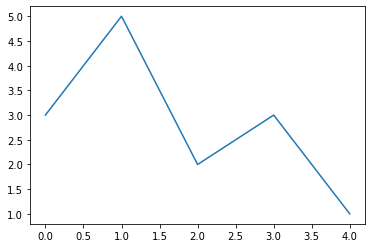

In [150]:
import matplotlib.pyplot as plt 
import numpy as np

def peakvalley(arr, reverse = False):
    arr.sort(reverse=reverse)

    for i in range(1, len(arr),2):
        prev = arr[i-1]
        curr = arr[i]
        arr[i-1] = curr
        arr[i] = prev
        if not reverse and prev == curr:
            peakvalley(arr, reverse=True)
arr = [5,3,1,2,3]
peakvalley(arr)
x = range(0, len(arr))
print(arr)
plt.plot(x, arr)